# Imports

In [1]:
import json
import itertools
import random
from pathlib import Path
from typing import Callable, Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
import torchvision.transforms.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import cv2

import albumentations as A

# Data

In [2]:
# Define dataset and model paths.
data_dir = Path("data")
train_dir = data_dir / "images/train"
test_dir = data_dir / "images/test"
model_dir = Path("models")
out_dir = Path("submission.json")
train_labels_path = data_dir / "annotations/instances_train.json"

# Training configuration: simple defaults used for the example run.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 3
num_iter = 20
batch_size = 8

# Random seed for reproducibility of experiments
seed = 0

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Augmentation

In [ ]:
pipeline = A.Compose([
        
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.2),
    A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=0.3),

    A.CoarseDropout(num_holes_range= (1, 8), hole_height_range= (0, 32), hole_width_range=(0, 32), p=0.15)

],
bbox_params= A.BboxParams(format='pascal_voc', label_fields=['category_ids'], clip=True, min_area=1.0))

with open(train_labels_path, 'r') as f:
        coco_data = json.load(f)

        annot = coco_data["annotations"]

# Apply augmentation

In [10]:
targets_list = []
train_list = []
for img_fname in train_dir.iterdir():
    img_id = int(img_fname.stem)
    boxes = [a["bbox"] for a in annot if a["image_id"] == img_id]
    if boxes == []:
        # Skip images without annotations (no RFIs)
        continue
    train_list.append(img_fname)
    for i, bbox in enumerate(boxes):
        x_min, y_min, w, h = bbox
        x_max = x_min + w
        y_max = y_min + h
        boxes[i] = [x_min, y_min, x_max, y_max]
    targets_list.append({
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor([1] * len(boxes), dtype=torch.int64)
    })

assert len(train_list) == len(targets_list) 

In [11]:
class RFIDataset(Dataset):
    """
    PyTorch Dataset for loading RFI (Radio Frequency Interference) detection images and their annotations.

    This dataset class handles loading images and their corresponding bounding box annotations,
    with optional image transformations.
    """

    def __init__(
            self,
            images: list[Path],
            targets: list[dict[str, torch.Tensor]] | None=None,
            transforms: Callable[[Any], Any] | None=None
        ):
        """
        Initialize the RFIDataset.

        Args:
            images (list): List of image file paths to load.
            targets (list, optional): List of target dictionaries containing 'boxes' and 'labels' tensors.
                                     If None, the dataset operates in inference mode. Defaults to None.
            transforms (callable, optional): Optional image transformation function to apply. Defaults to None.
        """
        self.images = images
        self.targets = targets
        self.transforms = transforms

    def __getitem__(self, idx: int) -> tuple[Image.Image | torch.Tensor, dict | None, Path]:
        """
        Get an image, its target annotations, and file path by index.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: A tuple containing:
                - img (PIL.Image or Tensor): The image, optionally transformed.
                - target (dict or None): Dictionary with 'boxes' and 'labels' tensors, or None if targets not provided.
                - img_path (Path): Path to the image file.
        """
        img_pil = Image.open(self.images[idx]).convert("RGB")
        img_np = np.array(img_pil)
        if self.targets is not None:
            target = {
                "boxes": self.targets[idx]["boxes"].clone(),
                "labels": self.targets[idx]["labels"].clone()
            }

        if self.transforms:
            if self.targets is not None:
                bboxes = target["boxes"].numpy().tolist()
                labels = target["labels"].numpy().tolist()

                transformed = self.transforms(image = img_np, bboxes = bboxes, category_ids = labels)

                img_np = transformed["image"]

                if len(transformed['bboxes']) > 0:
                    target["boxes"] = torch.tensor(transformed['bboxes'], dtype=torch.float32)
                    target["labels"] = torch.tensor(transformed['category_ids'], dtype=torch.int64)
                else:
                    target["boxes"] = torch.empty((0, 4), dtype=torch.float32)
                    target["labels"] = torch.empty((0,), dtype=torch.int64)

        else:
            transformed = self.transforms(image = img_np)
            img_np = transformed["image"]

        img_tensor = F.to_tensor(img_np)

        return img_tensor, target, self.images[idx]

    def __len__(self) -> int:
        """
        Get the total number of samples in the dataset.

        Returns:
            int: Number of images in the dataset.
        """
        return len(self.images)

In [12]:
train_data = RFIDataset(train_list, targets_list, transforms=pipeline)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Test augmentation

Batch size: 8
Image tensor shape: torch.Size([3, 342, 514])
Boxes tensor shape: torch.Size([2, 4])


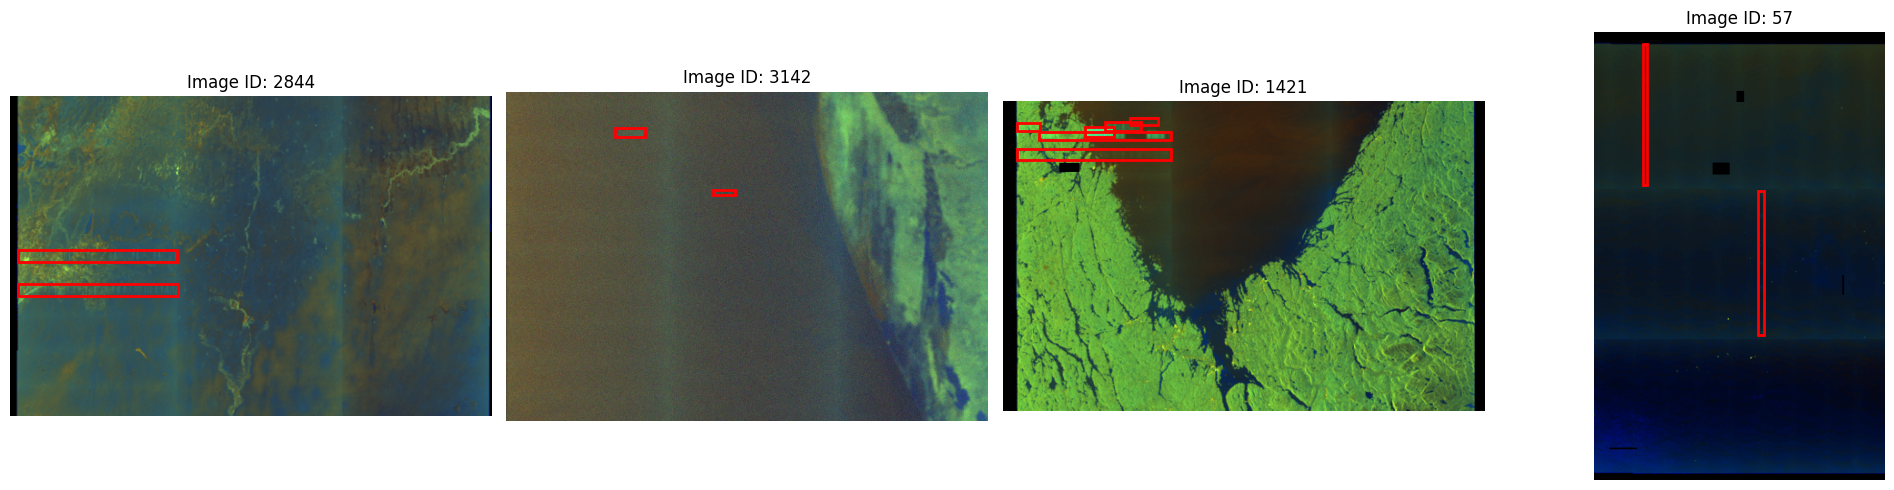

In [17]:
def verify_dataloader(dataloader):
    images, targets, paths = next(iter(dataloader))
    
    print(f"Batch size: {len(images)}")
    print(f"Image tensor shape: {images[0].shape}")
    print(f"Boxes tensor shape: {targets[0]['boxes'].shape}")
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i in range(min(4, len(images))):
        img_np = images[i].permute(1, 2, 0).numpy()
        
        ax = axes[i]
        ax.imshow(img_np)
        ax.set_title(f"Image ID: {paths[i].stem}")
        ax.axis("off")
        
        if targets[i] is not None and len(targets[i]['boxes']) > 0:
            boxes = targets[i]['boxes'].numpy()
            for box in boxes:
                x_min, y_min, x_max, y_max = box
                width = x_max - x_min
                height = y_max - y_min
                
                rect = patches.Rectangle(
                    (x_min, y_min), width, height, 
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                
    plt.tight_layout()
    plt.show()

verify_dataloader(train_loader)